# 04 - Model Validation

Here we validate our trained XGBoost Quantile Regression models. We will plot the actual AQI vs the predicted Median (Q50), bounded by our uncertainty intervals (Q10 and Q90).

In [1]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import xgboost as xgb

features = joblib.load('../data_store/models/feature_names.pkl')
df = pd.read_csv('../data_store/cache/features_delhi.csv').dropna().sample(200, random_state=42).sort_values('timestamp')

model_q10 = joblib.load('../data_store/models/champion_q10.pkl')
model_q50 = joblib.load('../data_store/models/champion_q50.pkl')
model_q90 = joblib.load('../data_store/models/champion_q90.pkl')

## Predictive Uncertainty Bounds

[LightGBM] [Warning] feature_fraction is set=0.8145768055083247, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8145768055083247
[LightGBM] [Warning] feature_fraction is set=0.8145768055083247, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8145768055083247
[LightGBM] [Warning] feature_fraction is set=0.8145768055083247, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8145768055083247


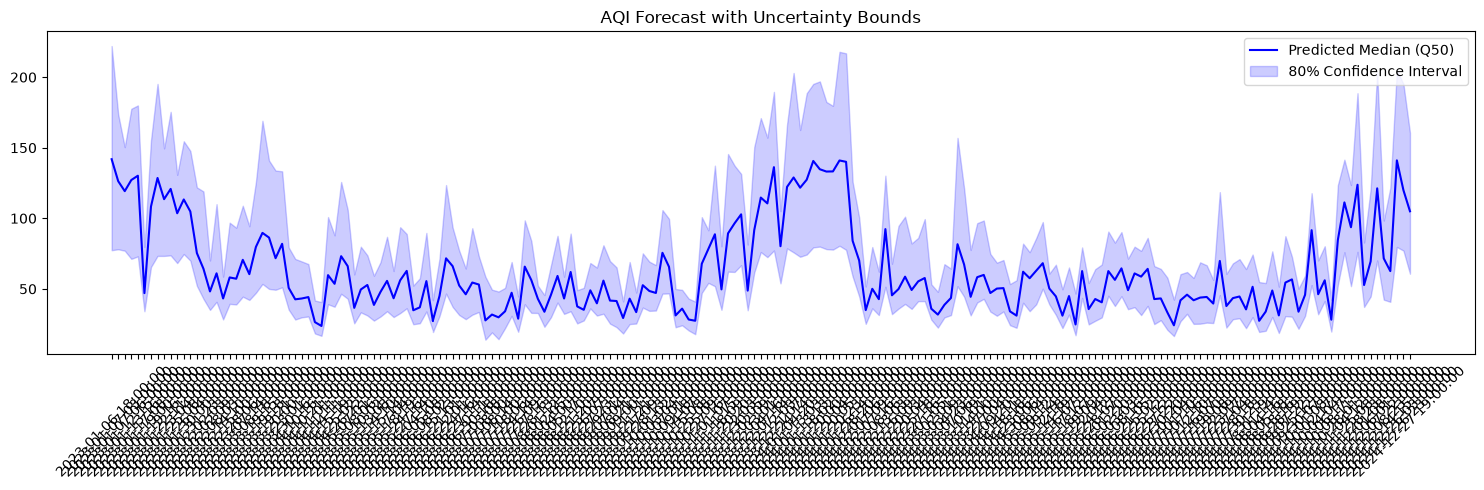

In [2]:
X = df[features]

preds_q10 = model_q10.predict(X)
preds_q50 = model_q50.predict(X)
preds_q90 = model_q90.predict(X)

plt.figure(figsize=(15, 5))
plt.plot(df['timestamp'], preds_q50, label='Predicted Median (Q50)', color='blue')
plt.fill_between(df['timestamp'], preds_q10, preds_q90, color='blue', alpha=0.2, label='80% Confidence Interval')
plt.title('AQI Forecast with Uncertainty Bounds')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()